# Caso de negocio: oportunidad gastronómica en Miami

**Decisión a apoyar:** dónde debería concentrar su investigación una empresa gastronómica que evalúa una nueva propuesta en Miami.

**Destinatario:** dirección de expansión o desarrollo de nuevos conceptos.

Este análisis parte del valor y las preferencias de los clientes. Yelp aparece después, como una muestra de la oferta observable, no como el centro del proyecto.

## 1. Punto de partida

El pipeline ya resolvió limpieza, trazabilidad e integración. Aquí no se repite el ETL: se usan sus salidas para responder tres preguntas.

1. ¿Dónde se concentra el valor de los clientes?
2. ¿Qué preferencias representan una demanda económicamente relevante?
3. ¿En cuáles hay señales de menor cobertura observada?

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import pandas as pd
import seaborn as sns
from IPython.display import HTML, Markdown, display

BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
ASSETS_DIR = BASE_DIR / "docs" / "assets"
ASSETS_DIR.mkdir(parents=True, exist_ok=True)

customers = pd.read_csv(BASE_DIR / "data" / "clean" / "customers_clean.csv")
miami = pd.read_csv(BASE_DIR / "data" / "final" / "customers_miami.csv")
customer_value = pd.read_csv(BASE_DIR / "data" / "final" / "customer_value_miami.csv")
restaurants = pd.read_csv(BASE_DIR / "data" / "clean" / "yelp_restaurants_clean.csv")
opportunity = pd.read_csv(BASE_DIR / "data" / "final" / "preference_opportunity_miami.csv")
quality = pd.read_csv(BASE_DIR / "docs" / "data_quality_report.csv")

COLORS = {
    "teal": "#278C82",
    "coral": "#D96C4B",
    "gold": "#D8A838",
    "blue": "#3D6F8E",
    "gray": "#69727D",
    "light": "#EEF2F4",
    "ink": "#1F2933",
}

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.titleweight": "bold",
    "axes.titlesize": 14,
    "axes.labelsize": 10,
    "font.size": 10,
})

In [2]:
total_spend = miami["gasto_periodo_estimado"].sum()
premium = customer_value.loc[
    (customer_value["dimension"] == "Membresia premium")
    & (customer_value["segment"] == "Sí")
].iloc[0]
high_value = customer_value.loc[
    (customer_value["dimension"] == "Estrato socioeconomico")
    & (customer_value["segment"] == "Muy Alto")
].iloc[0]
vegetarian = opportunity.loc[
    opportunity["customer_preference"] == "Vegetariano"
].iloc[0]
seafood = opportunity.loc[
    opportunity["customer_preference"] == "Mariscos"
].iloc[0]

display(Markdown(f"""
## Resumen ejecutivo

- La base analítica contiene **{len(miami):,} clientes de Miami** y **{total_spend:,.0f} unidades de gasto estimado por período**.
- Los clientes premium son **{premium["customer_share"]:.1%}** de la base, pero concentran **{premium["spend_share"]:.1%}** del gasto estimado.
- El estrato *Muy Alto* representa **{high_value["customer_share"]:.1%}** de los clientes y **{high_value["spend_share"]:.1%}** del gasto.
- **Mariscos** reúne el mayor gasto estimado por preferencia ({seafood["estimated_period_spend"]:,.0f}); **Vegetariano** muestra la mayor brecha relativa de cobertura ({vegetarian["demand_coverage_index"]:.2f}).
- La recomendación no es abrir un restaurante de inmediato: es priorizar validaciones de concepto, ubicación y disposición a pagar en esos dos espacios.
"""))


## Resumen ejecutivo

- La base analítica contiene **3,183 clientes de Miami** y **719,624 unidades de gasto estimado por período**.
- Los clientes premium son **53.2%** de la base, pero concentran **78.1%** del gasto estimado.
- El estrato *Muy Alto* representa **25.1%** de los clientes y **56.5%** del gasto.
- **Mariscos** reúne el mayor gasto estimado por preferencia (178,967); **Vegetariano** muestra la mayor brecha relativa de cobertura (1.42).
- La recomendación no es abrir un restaurante de inmediato: es priorizar validaciones de concepto, ubicación y disposición a pagar en esos dos espacios.


## 2. Dónde está el valor del cliente

La primera decisión no es qué cocina ofrecer, sino a quién servir. Se comparan participación de clientes y participación del gasto estimado para evitar confundir volumen con valor.

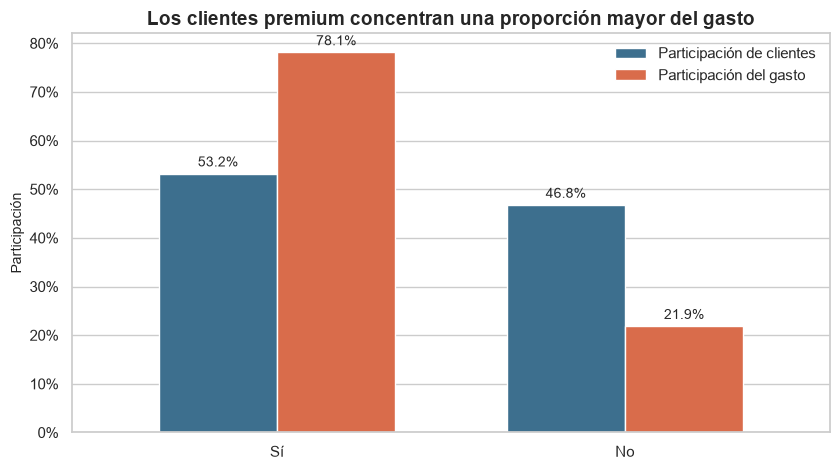

In [3]:
premium_view = (
    customer_value.loc[customer_value["dimension"] == "Membresia premium"]
    .set_index("segment")[["customer_share", "spend_share"]]
    .rename(columns={
        "customer_share": "Participación de clientes",
        "spend_share": "Participación del gasto",
    })
)

ax = premium_view.plot(
    kind="bar",
    figsize=(8.5, 4.8),
    color=[COLORS["blue"], COLORS["coral"]],
    width=0.68,
)
ax.set_title("Los clientes premium concentran una proporción mayor del gasto")
ax.set_xlabel("")
ax.set_ylabel("Participación")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.tick_params(axis="x", rotation=0)
ax.legend(frameon=False, loc="upper right")
ax.grid(axis="x", visible=False)

for container in ax.containers:
    ax.bar_label(container, labels=[f"{value:.1%}" for value in container.datavalues], padding=3)

plt.tight_layout()
plt.savefig(ASSETS_DIR / "01_customer_value_premium.png", dpi=170, bbox_inches="tight")
plt.show()

El promedio de gasto estimado por período es 331,91 para clientes premium y 105,68 para no premium. La membresía, sin embargo, está muy asociada al estrato socioeconómico; debe leerse como parte del perfil de valor y no como una causa aislada del gasto.

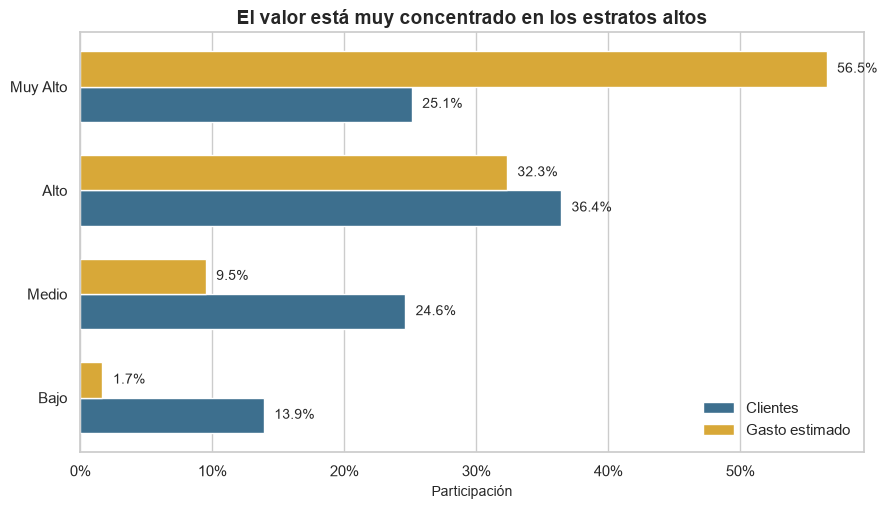

In [4]:
stratum = (
    customer_value.loc[customer_value["dimension"] == "Estrato socioeconomico"]
    .sort_values("estimated_period_spend")
)

fig, ax = plt.subplots(figsize=(9, 5.2))
y = range(len(stratum))
height = 0.34

ax.barh(
    [value - height / 2 for value in y],
    stratum["customer_share"],
    height=height,
    color=COLORS["blue"],
    label="Clientes",
)
ax.barh(
    [value + height / 2 for value in y],
    stratum["spend_share"],
    height=height,
    color=COLORS["gold"],
    label="Gasto estimado",
)

ax.set_yticks(list(y), stratum["segment"])
ax.set_title("El valor está muy concentrado en los estratos altos")
ax.set_xlabel("Participación")
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.legend(frameon=False, loc="lower right")
ax.grid(axis="y", visible=False)

for index, (_, row) in enumerate(stratum.iterrows()):
    ax.text(row["customer_share"] + 0.008, index - height / 2, f'{row["customer_share"]:.1%}', va="center")
    ax.text(row["spend_share"] + 0.008, index + height / 2, f'{row["spend_share"]:.1%}', va="center")

plt.tight_layout()
plt.savefig(ASSETS_DIR / "02_value_by_stratum.png", dpi=170, bbox_inches="tight")
plt.show()

### Lectura

El estrato *Muy Alto* concentra 56,5% del gasto con 25,1% de los clientes. Esto sugiere una propuesta orientada a valor y experiencia, pero todavía no define una cocina: esa elección requiere mirar preferencias y oferta.

## 3. Qué preferencias concentran demanda

Para priorizar preferencias se usa el gasto total estimado del segmento, no solamente su gasto promedio. Así se combinan tamaño de audiencia y comportamiento de consumo.

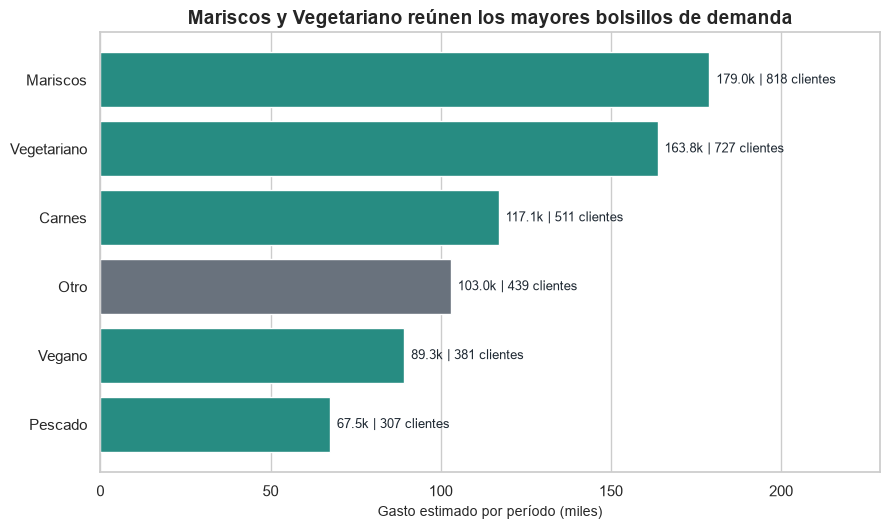

In [5]:
preference_value = (
    opportunity.sort_values("estimated_period_spend", ascending=True)
    .copy()
)
bar_colors = [
    COLORS["gray"] if quality_level == "Baja" else COLORS["teal"]
    for quality_level in preference_value["preference_data_quality"]
]

fig, ax = plt.subplots(figsize=(9, 5.4))
bars = ax.barh(
    preference_value["customer_preference"],
    preference_value["estimated_period_spend"] / 1000,
    color=bar_colors,
)
ax.set_title("Mariscos y Vegetariano reúnen los mayores bolsillos de demanda")
ax.set_xlabel("Gasto estimado por período (miles)")
ax.set_ylabel("")
ax.grid(axis="y", visible=False)

for bar, (_, row) in zip(bars, preference_value.iterrows()):
    label = f'{row["estimated_period_spend"] / 1000:.1f}k | {int(row["customer_count"]):,} clientes'
    ax.text(
        bar.get_width() + 2,
        bar.get_y() + bar.get_height() / 2,
        label,
        va="center",
        color=COLORS["ink"],
        fontsize=9,
    )

ax.set_xlim(0, preference_value["estimated_period_spend"].max() / 1000 * 1.28)
plt.tight_layout()
plt.savefig(ASSETS_DIR / "03_preference_value.png", dpi=170, bbox_inches="tight")
plt.show()

### Lectura

- **Mariscos:** 818 clientes y 178.967 unidades de gasto estimado; es el mayor bolsillo de demanda.
- **Vegetariano:** 727 clientes y 163.754 unidades; combina escala con una señal de menor cobertura.
- **Otro:** no debe entrar en el ranking estratégico. Un tercio del segmento proviene de preferencias faltantes imputadas.

## 4. Qué agrega la muestra de Yelp

Yelp se utiliza para comparar el peso de cada preferencia con la cobertura observada en 186 restaurantes de Miami. Un restaurante puede relacionarse con varias preferencias, por lo que la cobertura no representa cuota de mercado y sus porcentajes no tienen que sumar 100%.

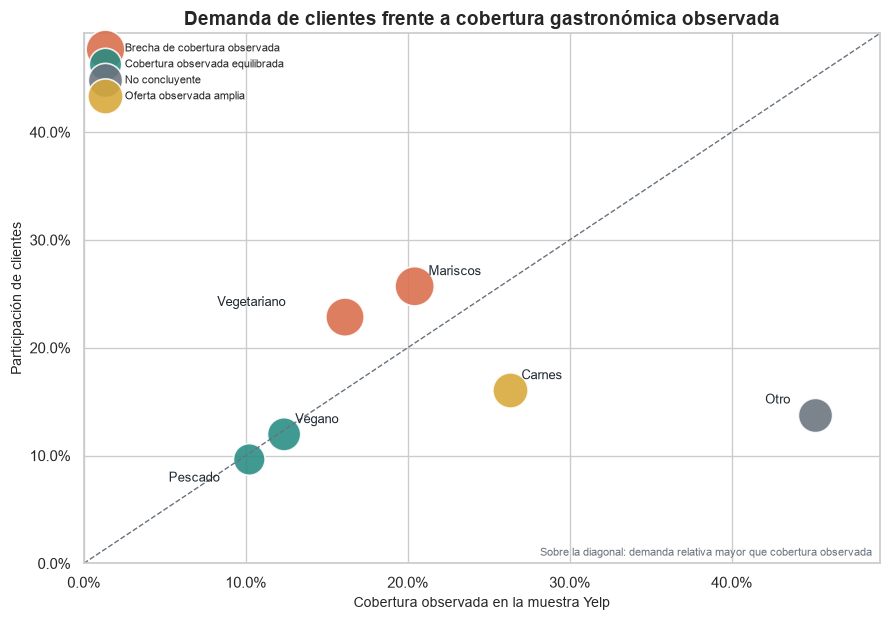

In [6]:
plot_data = opportunity.copy()
signal_colors = {
    "Brecha de cobertura observada": COLORS["coral"],
    "Cobertura observada equilibrada": COLORS["teal"],
    "Oferta observada amplia": COLORS["gold"],
    "No concluyente": COLORS["gray"],
}
offsets = {
    "Vegetariano": (-92, 8),
    "Mariscos": (10, 8),
    "Vegano": (8, 8),
    "Pescado": (-58, -16),
    "Carnes": (8, 8),
    "Otro": (-36, 8),
}

fig, ax = plt.subplots(figsize=(9, 6.3))
limit = max(
    plot_data["customer_share"].max(),
    plot_data["observed_restaurant_coverage"].max(),
) + 0.04
ax.plot([0, limit], [0, limit], linestyle="--", color=COLORS["gray"], linewidth=1)

for signal, group in plot_data.groupby("coverage_signal"):
    ax.scatter(
        group["observed_restaurant_coverage"],
        group["customer_share"],
        s=350 + group["estimated_period_spend_share"] * 1800,
        color=signal_colors[signal],
        alpha=0.88,
        edgecolor="white",
        linewidth=1.2,
        label=signal,
    )
    for _, row in group.iterrows():
        ax.annotate(
            row["customer_preference"],
            (row["observed_restaurant_coverage"], row["customer_share"]),
            xytext=offsets[row["customer_preference"]],
            textcoords="offset points",
            fontsize=9,
            color=COLORS["ink"],
        )

ax.set_title("Demanda de clientes frente a cobertura gastronómica observada")
ax.set_xlabel("Cobertura observada en la muestra Yelp")
ax.set_ylabel("Participación de clientes")
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_xlim(0, limit)
ax.set_ylim(0, limit)
ax.legend(frameon=False, fontsize=8, loc="upper left")
ax.text(
    0.99,
    0.01,
    "Sobre la diagonal: demanda relativa mayor que cobertura observada",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=8,
    color=COLORS["gray"],
)

plt.tight_layout()
plt.savefig(ASSETS_DIR / "04_demand_vs_coverage.png", dpi=180, bbox_inches="tight")
plt.show()

Vegetariano y Mariscos quedan por encima de la diagonal: su peso en clientes supera su cobertura relativa en la muestra. Carnes queda por debajo y parece enfrentar una oferta amplia; allí tendría más sentido competir por diferenciación que por disponibilidad.

## 5. Prioridades recomendadas

La tabla final separa señal de mercado, calidad del dato y acción sugerida. No convierte un índice en una decisión automática.

In [7]:
priority = opportunity.loc[
    opportunity["preference_data_quality"] != "Baja",
    [
        "customer_preference",
        "customer_count",
        "estimated_period_spend",
        "demand_coverage_index",
        "coverage_signal",
        "recommended_action",
    ],
].sort_values(
    ["coverage_signal", "estimated_period_spend"],
    ascending=[True, False],
)

priority_table = (
    priority.rename(columns={
        "customer_preference": "Preferencia",
        "customer_count": "Clientes",
        "estimated_period_spend": "Gasto estimado",
        "demand_coverage_index": "Índice demanda/cobertura",
        "coverage_signal": "Señal",
        "recommended_action": "Siguiente decisión",
    }).style.set_uuid("priority").format({
        "Clientes": "{:,.0f}",
        "Gasto estimado": "{:,.0f}",
        "Índice demanda/cobertura": "{:.2f}",
    }).hide(axis="index")
)
display(HTML(priority_table.to_html()))

Preferencia,Clientes,Gasto estimado,Índice demanda/cobertura,Señal,Siguiente decisión
Mariscos,818,"178,967",1.26,Brecha de cobertura observada,"Validar concepto, ubicacion y disposicion a pagar"
Vegetariano,727,"163,754",1.42,Brecha de cobertura observada,"Validar concepto, ubicacion y disposicion a pagar"
Vegano,381,"89,310",0.97,Cobertura observada equilibrada,"Evaluar nichos, ticket y ubicacion antes de expandir"
Pescado,307,"67,520",0.94,Cobertura observada equilibrada,"Evaluar nichos, ticket y ubicacion antes de expandir"
Carnes,511,"117,067",0.61,Oferta observada amplia,"Competir por diferenciacion, no por volumen de oferta"


### Recomendación

1. **Validar primero Vegetariano y Mariscos.** Ambos combinan tamaño económico con una brecha de cobertura observada.
2. **Diseñar la propuesta para clientes de alto valor.** Premium y estrato alto concentran el gasto, pero deben analizarse juntos por su fuerte asociación.
3. **No usar Otro para decidir.** Primero hay que separar preferencias realmente declaradas de valores imputados.
4. **No presentar Yelp como censo.** La siguiente validación debe incorporar ubicación, precios, competencia directa y una muestra más controlada.

## 6. Limitaciones que cambian la interpretación

- El dataset de clientes proviene de una entrega educativa y no incluye documentación de licencia o representatividad.
- frecuencia_visita no especifica su unidad temporal; por eso se habla de gasto **por período**, no mensual.
- Yelp es una muestra limitada y ordenada por su API, no el universo de restaurantes de Miami.
- Las categorías se superponen: un restaurante puede cubrir varias preferencias.
- Membresía premium y estrato socioeconómico están asociados; el análisis describe relación, no causalidad.
- El estudio es transversal. Antes de invertir hacen falta validaciones de ubicación, precio y disposición a pagar.

## Apéndice: control del pipeline

La calidad de datos es una condición de entrada, no el resultado de negocio. Se deja al final para mantener la narrativa enfocada en decisiones.

In [8]:
quality_view = quality[
    ["dataset", "step", "rows", "columns", "missing_total", "duplicate_rows"]
].copy()

quality_table = (
    quality_view.rename(columns={
        "dataset": "Dataset",
        "step": "Etapa",
        "rows": "Filas",
        "columns": "Columnas",
        "missing_total": "Nulos",
        "duplicate_rows": "Duplicados",
    }).style.set_uuid("quality").format({
        "Filas": "{:,.0f}",
        "Columnas": "{:,.0f}",
        "Nulos": "{:,.0f}",
        "Duplicados": "{:,.0f}",
    }).hide(axis="index")
)
display(HTML(quality_table.to_html()))

Dataset,Etapa,Filas,Columnas,Nulos,Duplicados
customers,raw,"30,000",17,"31,887",0
customers,clean,"29,978",18,0,0
customers,final_miami,"3,183",18,0,0
yelp,raw,240,15,137,0
yelp,clean,186,25,0,0
customer_value,final,6,9,0,0
preference_opportunity,final,6,19,0,0


## Conclusión para dirección de expansión

Con los datos disponibles, **Vegetariano y Mariscos son las dos preferencias que deberían pasar a validación comercial**.

- **Vegetariano** combina 727 clientes, 163.754 unidades de gasto estimado y la mayor brecha de cobertura observada (1,42).
- **Mariscos** reúne el mayor gasto estimado, 178.967 unidades, y también queda por encima del equilibrio de cobertura (1,26).
- **Carnes** muestra una oferta observada amplia; una propuesta nueva necesitaría diferenciarse por experiencia, ubicación o precio.
- **Otro** no debe usarse para decidir hasta separar respuestas declaradas de preferencias imputadas.

La recomendación es comparar zonas, precios y competidores directos para Vegetariano y Mariscos, y después validar disposición a pagar con clientes premium y de estratos altos. El proyecto deja esas prioridades respaldadas por un ETL reproducible, controles de calidad y reglas de negocio visibles.